# General Overview

NASA DONKI (Database Of Notifications, Knowledge, Information) Space Weather Events is a tabular dataset of space weather activity collected by NASA's Community Coordinated Modeling Center. It includes events such as coronal mass ejections, geomagnetic storms, interplanetary shocks, high-speed streams, and solar energetic particle events.

The dataset is useful for studying the full Sun-to-Earth chain of space weather because it preserves causal relationships through the `linked_events` field. That makes it possible to trace how one event may trigger another, for example CME -> IPS -> GST.

A few useful points about the dataset:
- coverage starts in 2010 and continues to the present
- the current Hugging Face snapshot contains 10,899 events
- it is suitable for tabular classification and time-series forecasting tasks
- it is updated daily, so the row count can change over time

Reference Terms

- CME: coronal mass ejection, a burst of plasma and magnetic field from the Sun
- GST: geomagnetic storm, a disturbance in Earth's magnetic field caused by solar activity
- IPS: interplanetary shock, a shock wave traveling through the solar wind
- HSS: high-speed stream, a fast flow of solar wind often coming from coronal holes
- SEP: solar energetic particle event, high-energy particles accelerated by flares or CMEs
- Kp index: a global scale that measures geomagnetic disturbance
- Dst index: a measure of the strength of the ring current during storms
- IMF: interplanetary magnetic field, the magnetic field carried by the solar wind
- Bz: the north-south magnetic component of the IMF; sustained negative Bz is important for storm triggering
- L1 point: the location between the Sun and Earth where spacecraft can monitor the solar wind before it reaches Earth
- heliographic coordinates: a Sun-based coordinate system used to describe where solar events originate
- active region: a magnetically active area on the Sun where flares and CMEs can begin
- geoeffective: likely to produce effects on Earth's magnetosphere or technology
- transit time: the travel time from a solar eruption to its arrival near Earth
- halo CME: a CME that appears to surround the Sun in coronagraph images, often suggesting an Earth-directed event
- coronagraph: an instrument that blocks the bright solar disk so the faint solar corona can be observed
- magnetosphere: the region around Earth dominated by Earth's magnetic field
- magnetic reconnection: a process where magnetic field lines rearrange and release energy

This notebook will use the DONKI data to understand event types, event timing, and how solar activity connects to geomagnetic storms.

In [ ]:
pip install -r requirements.txt

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
# url = "https://huggingface.co/datasets/juliensimon/donki-space-weather-events/resolve/main/data/donki_events.parquet"
# df = pd.read_parquet(url)

# pip install datasets
%pip install datasets
from datasets import load_dataset

ds = load_dataset("juliensimon/donki-space-weather-events", split="train")
df = ds.to_pandas()

In [56]:
print(f"{df.shape[0]} rows, {df.shape[1]} columns") 

10903 rows, 17 columns


In [57]:
df.columns.to_list()

['event_type',
 'activity_id',
 'start_time',
 'source_location',
 'active_region',
 'note',
 'link',
 'cme_speed_kms',
 'cme_half_angle_deg',
 'cme_latitude',
 'cme_longitude',
 'cme_type',
 'cme_time_21_5',
 'cme_measurement',
 'linked_events',
 'gst_max_kp',
 'gst_kp_count']

In [58]:
df.head(7)

,event_type,activity_id,start_time,source_location,active_region,note,link,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type,cme_time_21_5,cme_measurement,linked_events,gst_max_kp,gst_kp_count
0,IPS,2010-01-20T20:20:00-IPS-001,2010-01-20 20:20:00+00:00,NaN,NaN,STEREO B,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/IP...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,IPS,2010-02-05T03:33:00-IPS-001,2010-02-05 03:33:00+00:00,NaN,NaN,STEREO A,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/IP...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,IPS,2010-02-14T07:50:00-IPS-001,2010-02-14 07:50:00+00:00,NaN,NaN,STEREO B,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/IP...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,IPS,2010-03-05T18:25:00-IPS-001,2010-03-05 18:25:00+00:00,NaN,NaN,STEREO A,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/IP...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4,CME,2010-04-03T09:54:00-CME-001,2010-04-03 09:54:00+00:00,S20E05,NaN,SDO images were unavailable. CME source locati...,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/CM...,620.0,26.0,7.0,8.0,C,2010-04-03 17:16:00+00:00,null,"2010-04-03T09:04:00-FLR-001, 2010-04-05T07:54:...",NaN,NaN
5,IPS,2010-04-05T07:54:00-IPS-001,2010-04-05 07:54:00+00:00,NaN,NaN,Earth,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/IP...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,2010-04-03T09:54:00-CME-001,NaN,NaN
6,GST,2010-04-05T12:00:00-GST-001,2010-04-05 12:00:00+00:00,NaN,NaN,NaN,https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/GS...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,7.0,1.0


In [59]:
df.groupby("event_type").count()

,activity_id,start_time,source_location,active_region,note,link,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type,cme_time_21_5,cme_measurement,linked_events,gst_max_kp,gst_kp_count
event_type,,,,,,,,,,,,,,,,
CME,8091,8091,2675,1548,8091,8091,8016,8016,8007,6968,8016,8014,8016,1592,0,0
GST,197,197,0,0,0,197,0,0,0,0,0,0,0,181,197,197
HSS,775,775,0,0,0,775,0,0,0,0,0,0,0,361,0,0
IPS,1363,1363,0,0,1363,1363,0,0,0,0,0,0,0,1063,0,0
SEP,477,477,0,0,0,477,0,0,0,0,0,0,0,461,0,0


## Missing Values: Structural vs. Genuine

The `count()` above shows raw non-null counts. To decide what to do with missing values, it helps to look at the **fraction missing per event type** instead. A null can mean two very different things:

- **Structurally not-applicable** — e.g. `cme_speed_kms` is null for a GST because a geomagnetic storm has no CME speed. The value isn't missing, it's *undefined*. These nulls are correct and should **not** be imputed or filled with 0 (a `cme_speed_kms` of 0 would falsely claim "a CME at rest").
- **Genuinely missing** — a column that is null *even within the event type it describes* (e.g. CME rows that lack `cme_longitude`). These are real candidates for imputation, flagging, or dropping.

The table below reads column-by-column: look for high values in the "wrong" event-type rows (structural) versus high values in the row the column belongs to (genuine missingness).

In [60]:
# Fraction of values missing in each column, broken down by event type.
# Rows = event type, columns = fields. Higher = more missing.
null_fraction_by_type = (
    df.groupby("event_type")
      .apply(lambda g: g.isnull().mean(), include_groups=False)
      .round(2)
)
null_fraction_by_type

,activity_id,start_time,source_location,active_region,note,link,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type,cme_time_21_5,cme_measurement,linked_events,gst_max_kp,gst_kp_count
event_type,,,,,,,,,,,,,,,,
CME,0.0,0.0,0.67,0.81,0.0,0.0,0.01,0.01,0.01,0.14,0.01,0.01,0.01,0.80,1.0,1.0
GST,0.0,0.0,1.00,1.00,1.0,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.08,0.0,0.0
HSS,0.0,0.0,1.00,1.00,1.0,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.53,1.0,1.0
IPS,0.0,0.0,1.00,1.00,0.0,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.22,1.0,1.0
SEP,0.0,0.0,1.00,1.00,1.0,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.03,1.0,1.0


## Visualizing the Data

A few plots to get a feel for the dataset before modeling. We look at four things:

1. **How common each event type is** — the dataset is dominated by CMEs, so it helps to see the balance.
2. **CME speed distribution** — speed is the headline CME feature and a likely storm predictor.
3. **Events over time** — activity should track the ~11-year solar cycle.
4. **Storm severity (peak Kp)** — the distribution of the value we ultimately want to predict.

A note on filtering: every plot below first restricts to the relevant `event_type`, so we never plot the structural nulls discussed above (e.g. CME speed only exists for CME rows).

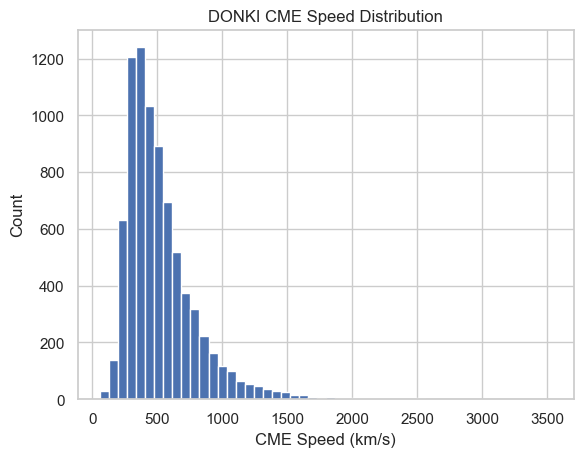

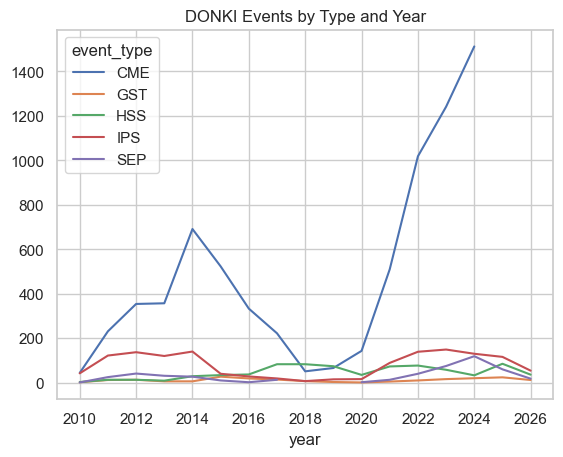

In [61]:
# Fast CMEs (potential Earth-directed storms)
fast_cmes = df[(df["event_type"] == "CME") & (df["cme_speed_kms"] > 1000)]

# Geomagnetic storms with linked CMEs
storms = df[df["event_type"] == "GST"]
storms_with_cme = storms[storms["linked_events"].str.contains("CME", na=False)]

# CME speed distribution
cmes = df[df["event_type"] == "CME"]
cmes["cme_speed_kms"].hist(bins=50)
plt.xlabel("CME Speed (km/s)")
plt.ylabel("Count")
plt.title("DONKI CME Speed Distribution")
plt.show()

# Event frequency by type and year
df["year"] = df["start_time"].dt.year
df.groupby(["year", "event_type"]).size().unstack().plot()
plt.title("DONKI Events by Type and Year")
plt.show()

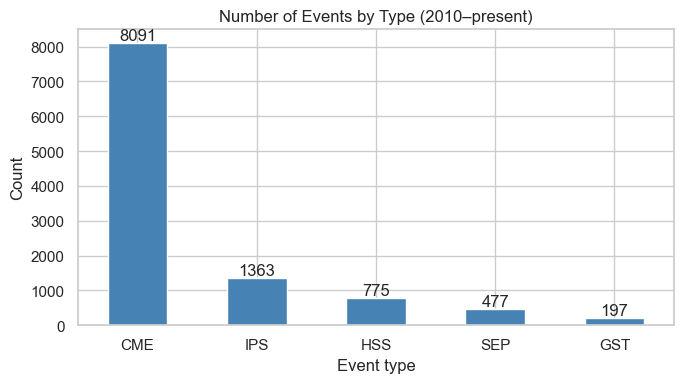

In [62]:
# 1. How common is each event type?
event_counts = df["event_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
event_counts.plot.bar(ax=ax, color="steelblue")
ax.bar_label(ax.containers[0])              # annotate each bar with its count
ax.set_title("Number of Events by Type (2010–present)")
ax.set_xlabel("Event type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

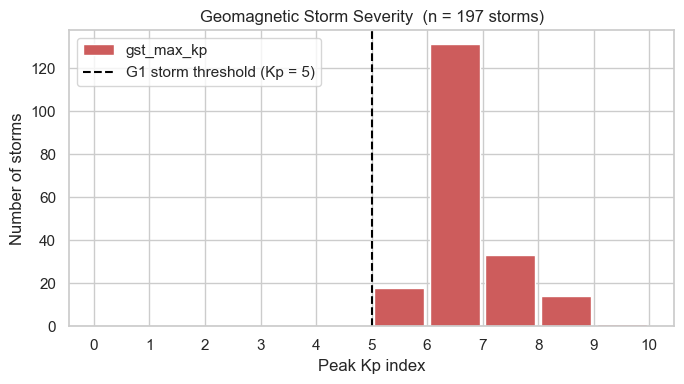

In [63]:
# 2. Storm severity: distribution of peak Kp for geomagnetic storms (GST).
# This is the quantity the project ultimately wants to predict.
storms = df[df["event_type"] == "GST"]

fig, ax = plt.subplots(figsize=(7, 4))
storms["gst_max_kp"].plot.hist(bins=range(0, 11), rwidth=0.9, ax=ax, color="indianred")
ax.axvline(5, color="black", linestyle="--", label="G1 storm threshold (Kp = 5)")
ax.set_title(f"Geomagnetic Storm Severity  (n = {len(storms)} storms)")
ax.set_xlabel("Peak Kp index")
ax.set_ylabel("Number of storms")
ax.set_xticks(range(0, 11))
ax.legend()
plt.tight_layout()
plt.show()

## Outlier Detection & Relationships

The plots above describe single columns. This section gives the group the tools to (a) **spot outliers** in the CME measurements and (b) **see relationships** between features and storm outcomes — the two things needed to make informed cleaning and modeling decisions.

All cells operate on a `cme` slice (CME events only) so we're working with genuinely-populated numeric columns, not structural nulls.

> An "outlier" here is a flag for review, not automatically an error. A 3,500 km/s CME is a real, extreme event — not noise to delete. Use these views to *decide* what each extreme value is, not to blindly remove it.

In [64]:
# CME-only slice and its numeric measurement columns.
cme = df[df["event_type"] == "CME"].copy()
num_cols = ["cme_speed_kms", "cme_half_angle_deg", "cme_latitude", "cme_longitude"]

# Summary statistics: a first look at scale, spread, and extremes (min/max).
cme[num_cols].describe().round(1)

,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude
count,8016.0,8016.0,8007.0,6968.0
mean,525.9,26.5,-0.9,0.5
std,281.7,11.6,32.0,93.9
min,60.0,2.0,-90.0,-180.0
25%,337.0,17.0,-23.0,-84.0
50%,456.0,25.0,-1.0,0.0
75%,634.0,34.0,21.0,86.0
max,3529.0,92.0,90.0,180.0


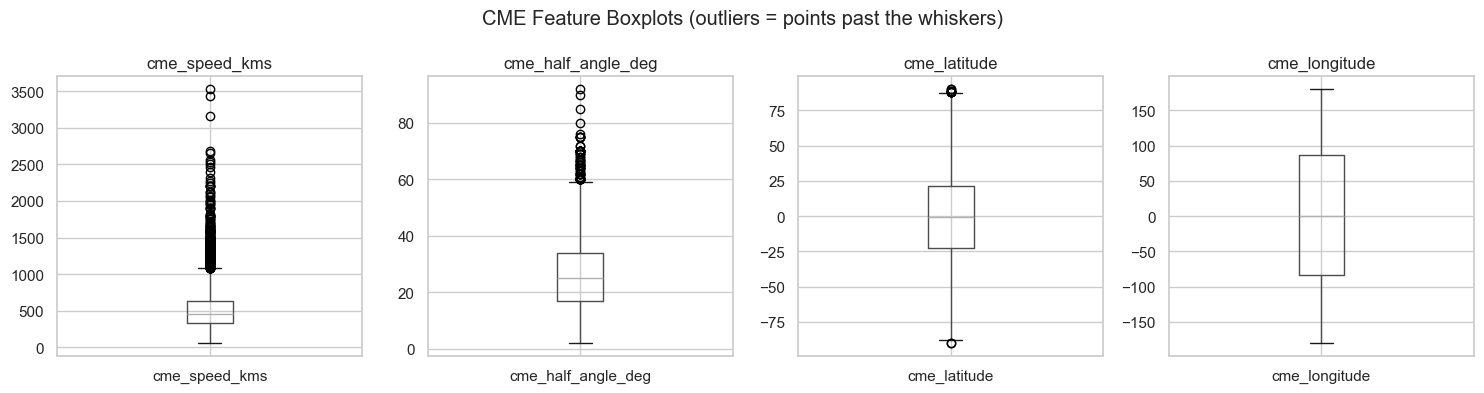

In [65]:
# Boxplots — the fastest visual way to spot outliers.
# Points beyond the whiskers (1.5 x IQR) are flagged as potential outliers.
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    cme.boxplot(column=col, ax=ax)
    ax.set_title(col)
fig.suptitle("CME Feature Boxplots (outliers = points past the whiskers)")
plt.tight_layout()
plt.show()

In [66]:
# Quantify the outliers with the IQR rule, so the decision isn't purely visual.
# Returns how many values fall outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] per column.
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return pd.Series({
        "n_outliers": int(mask.sum()),
        "pct": round(100 * mask.mean(), 1),
        "low_cut": round(lo, 1),
        "high_cut": round(hi, 1),
    })

cme[num_cols].apply(iqr_outliers).T

,n_outliers,pct,low_cut,high_cut
cme_speed_kms,376.0,4.6,-108.5,1079.5
cme_half_angle_deg,87.0,1.1,-8.5,59.5
cme_latitude,12.0,0.1,-89.0,87.0
cme_longitude,0.0,0.0,-339.0,341.0


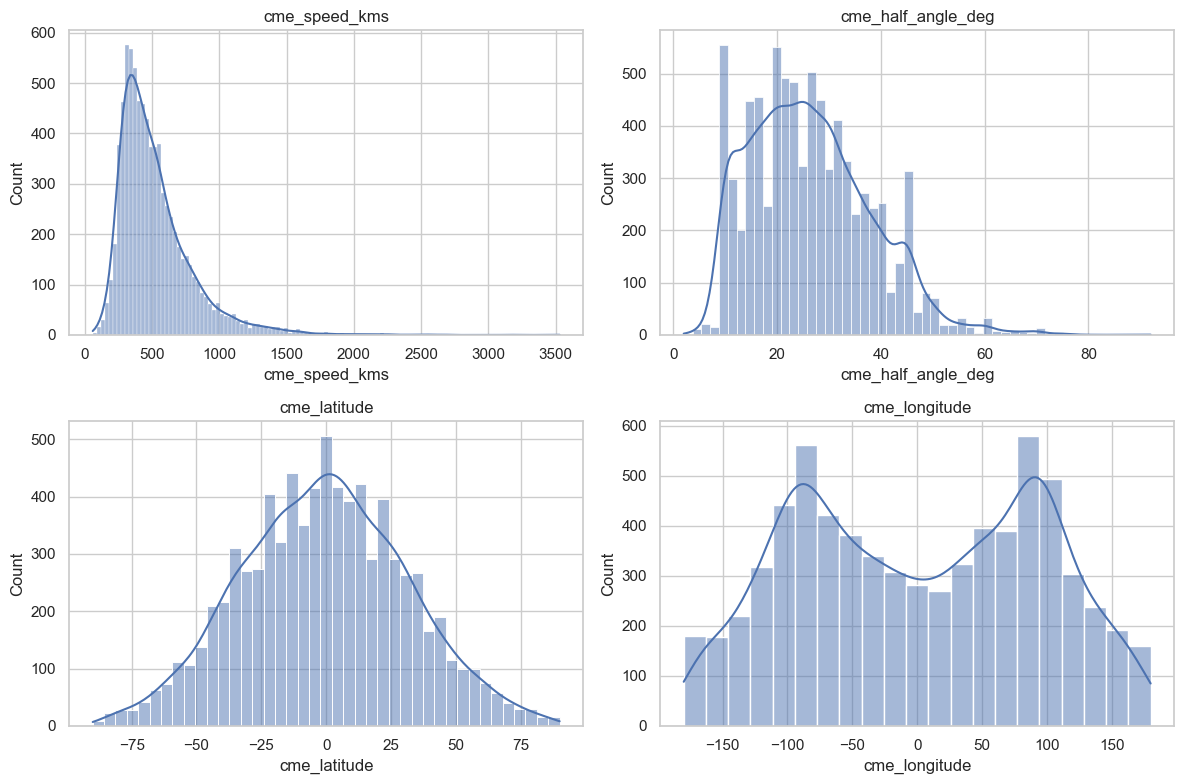

In [67]:
# Distribution shape — histograms with a KDE overlay.
# Tells you WHY there are outliers: skew vs. true bimodality vs. heavy tails.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(cme[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

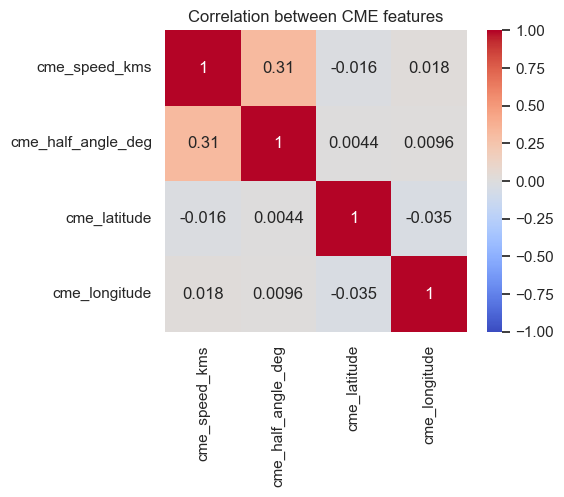

In [68]:
# Correlation heatmap — which CME features move together?
# Helps spot redundant features and sanity-check physics (e.g. speed vs width).
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cme[num_cols].corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation between CME features")
plt.tight_layout()
plt.show()

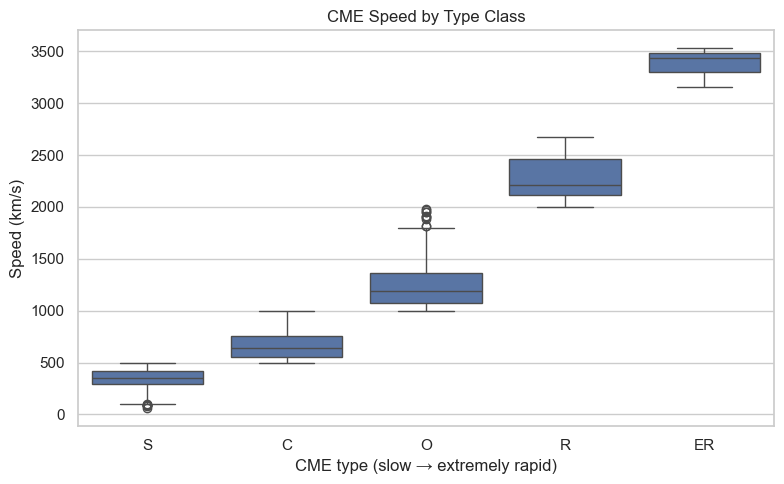

In [69]:
# Speed by CME type class (S=slow ... ER=extremely rapid).
# Validates the type labels and shows where the fast outliers concentrate.
order = [t for t in ["S", "C", "O", "R", "ER"] if t in cme["cme_type"].dropna().unique()]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=cme, x="cme_type", y="cme_speed_kms", order=order, ax=ax)
ax.set_title("CME Speed by Type Class")
ax.set_xlabel("CME type (slow → extremely rapid)")
ax.set_ylabel("Speed (km/s)")
plt.tight_layout()
plt.show()

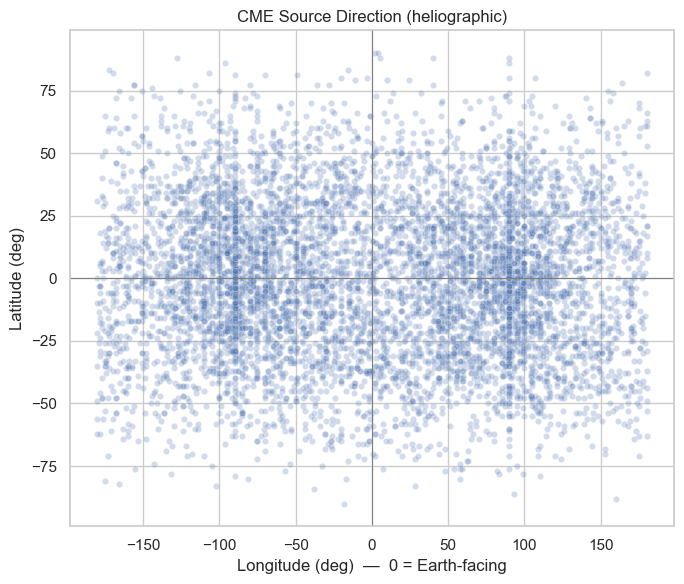

In [70]:
# Source direction — where on the Sun do CMEs originate?
# Longitude near 0 (central meridian) means Earth-directed and more geoeffective.
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=cme, x="cme_longitude", y="cme_latitude", alpha=0.25, s=20, ax=ax)
ax.axvline(0, color="grey", lw=0.8)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("CME Source Direction (heliographic)")
ax.set_xlabel("Longitude (deg)  —  0 = Earth-facing")
ax.set_ylabel("Latitude (deg)")
plt.tight_layout()
plt.show()

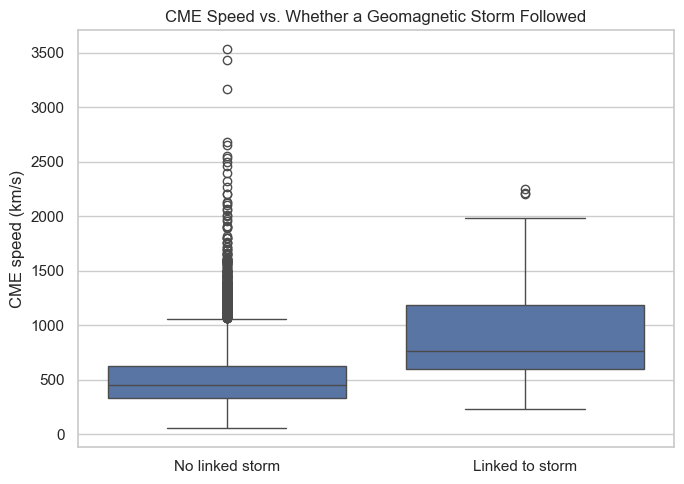

Median CME speed (km/s):
storm_outcome
Linked to storm    763.0
No linked storm    452.0
Name: cme_speed_kms, dtype: float64


In [71]:
# THE KEY RELATIONSHIP: does CME speed predict whether a storm follows?
# A CME is "linked to a storm" if its activity_id appears in any GST's linked_events.
gst_links = df.loc[df["event_type"] == "GST", "linked_events"].dropna()
linked_cme_ids = {
    tok.strip()
    for s in gst_links
    for tok in s.split(",")
    if "CME" in tok
}
cme["led_to_storm"] = cme["activity_id"].isin(linked_cme_ids)
cme["storm_outcome"] = cme["led_to_storm"].map({True: "Linked to storm", False: "No linked storm"})

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=cme, x="storm_outcome", y="cme_speed_kms",
            order=["No linked storm", "Linked to storm"], ax=ax)
ax.set_title("CME Speed vs. Whether a Geomagnetic Storm Followed")
ax.set_xlabel("")
ax.set_ylabel("CME speed (km/s)")
plt.tight_layout()
plt.show()

print("Median CME speed (km/s):")
print(cme.groupby("storm_outcome")["cme_speed_kms"].median().round(0))